# Notebook 4: Evaluation, Fairness Audit & Explainability
### EEEM073 — AI and Sustainability | University of Surrey | 2025–2026
Evaluates all models on 2024 test data, conducts fairness audit, applies SHAP.
**Inputs:** Saved model weights + edm_site_imd.csv
**Outputs:** Figures 13–17, test_predictions.csv, fairness_metrics.csv, policy_lever_table.csv

## Step 1: Imports

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import joblib
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'Arial'
plt.rcParams['font.size']      = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

PROCESSED = "../data/processed/"
OUTPUTS   = "../outputs/"
os.makedirs(OUTPUTS, exist_ok=True)

print(f"Device: {device}")
print("All imports successful")

Device: mps
All imports successful


## Step 2: Reconstruct Data Pipeline
Exact same feature set and split as Notebook 3.

In [ ]:

import os
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

raw = pd.read_csv(f"{PROCESSED}edm_site_imd.csv")
raw = raw.loc[:, ~raw.columns.duplicated(keep='first')].reset_index(drop=True)
print(f"Shape: {raw.shape} | Duplicate cols: {raw.columns.duplicated().sum()}")

le_company = LabelEncoder()
raw['company_encoded'] = le_company.fit_transform(raw['company'].fillna('Unknown'))

feature_cols = [
    'spill_count_avg', 'edm_pct_operational', 'avg_spill_duration_hrs',
    'spill_severity', 'yoy_change', 'site_imd_score',
    'company_imd_score', 'year', 'company_encoded'
]
target_col = 'spill_count'

keep_cols = (feature_cols + [target_col, 'unique_id',
             'site_imd_quintile', 'monitor_reliable', 'company'])
model_df = raw[keep_cols].dropna().reset_index(drop=True)
print(f"Model df: {model_df.shape}")

site_to_idx          = {s: i for i, s in enumerate(model_df['unique_id'].unique())}
model_df['site_idx'] = model_df['unique_id'].map(site_to_idx)
n_sites              = len(site_to_idx)
n_features           = len(feature_cols)
print(f"Sites: {n_sites} | Features: {n_features}")

year_vals  = model_df['year'].values.astype(int)
train_mask = year_vals == 2023
test_mask  = year_vals == 2024

train_rows = model_df[train_mask].reset_index(drop=True)
test_rows  = model_df[test_mask].reset_index(drop=True)
print(f"Train: {len(train_rows)} | Test: {len(test_rows)}")

X_tr = train_rows[feature_cols].values.astype(np.float32)
y_tr = train_rows[target_col].values.astype(np.float32)
s_tr = train_rows['site_idx'].values.astype(np.int64)

X_te = test_rows[feature_cols].values.astype(np.float32)
y_te = test_rows[target_col].values.astype(np.float32)
s_te = test_rows['site_idx'].values.astype(np.int64)

# Scale
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_test_s = scaler.transform(X_te)

# Test metadata
test_meta = test_rows[['unique_id', 'site_imd_quintile',
                        'monitor_reliable', 'company',
                        target_col]].copy().reset_index(drop=True)

print(f"Test metadata: {test_meta.shape}")
print(f"Deprivation groups:\n{test_meta['site_imd_quintile'].value_counts().sort_index()}")
print("Cell 2 complete")

Shape: (28632, 34) | Duplicate cols: 0
Model df: (27415, 14)
Sites: 25252 | Features: 9
Train: 13206 | Test: 14209
Test metadata: (14209, 5)
Deprivation groups:
site_imd_quintile
Q1\n(most deprived)    3014
Q2                     5981
Q3                     3216
Q4                     1998
Name: count, dtype: int64
Cell 2 complete


## Step 3: Load All Model Weights
Models loaded to CPU first then moved to MPS to prevent memory allocation errors on Apple Silicon.

In [ ]:

import os
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'

class SpillDataset(Dataset):
    def __init__(self, X, y, site_ids):
        self.X        = torch.FloatTensor(X)
        self.y        = torch.FloatTensor(y)
        self.site_ids = torch.LongTensor(site_ids)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.site_ids[idx], self.y[idx]

class SpillLSTM(nn.Module):
    def __init__(self, n_features, n_sites, embedding_dim=16,
                 hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.site_embedding = nn.Embedding(n_sites, embedding_dim, padding_idx=0)
        self.lstm    = nn.LSTM(n_features + embedding_dim, hidden_dim,
                               n_layers,
                               dropout=dropout if n_layers > 1 else 0,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_dim, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)
    def forward(self, x, site_ids):
        emb    = self.site_embedding(site_ids)
        x_seq  = torch.cat([x, emb], dim=1).unsqueeze(1)
        out, _ = self.lstm(x_seq)
        out    = self.dropout(out[:, -1, :])
        return self.fc2(self.relu(self.fc1(out))).squeeze(1)

class SpillPINN(nn.Module):
    def __init__(self, n_features, n_sites, embedding_dim=16,
                 hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.site_embedding = nn.Embedding(n_sites, embedding_dim, padding_idx=0)
        self.lstm    = nn.LSTM(n_features + embedding_dim, hidden_dim,
                               n_layers,
                               dropout=dropout if n_layers > 1 else 0,
                               batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_dim, 32)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(32, 1)
        self.log_k   = nn.Parameter(torch.tensor(-2.3))
    def forward(self, x, site_ids):
        emb    = self.site_embedding(site_ids)
        x_seq  = torch.cat([x, emb], dim=1).unsqueeze(1)
        out, _ = self.lstm(x_seq)
        out    = self.dropout(out[:, -1, :])
        return self.fc2(self.relu(self.fc1(out))).squeeze(1)

# Load Attention-LSTM
class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Linear(hidden_dim, 1)
    def forward(self, lstm_output):
        scores  = self.attention(lstm_output)
        weights = torch.softmax(scores, dim=1)
        context = (weights * lstm_output).sum(dim=1)
        return context, weights.squeeze(-1)

class SpillAttentionLSTM(nn.Module):
    def __init__(self, n_features, n_sites, embedding_dim=16,
                 hidden_dim=64, n_layers=2, dropout=0.3, seq_len=4):
        super().__init__()
        self.seq_len        = seq_len
        self.site_embedding = nn.Embedding(n_sites, embedding_dim, padding_idx=0)
        self.feature_proj   = nn.Linear(n_features + embedding_dim, hidden_dim)
        self.lstm           = nn.LSTM(hidden_dim, hidden_dim, n_layers,
                                      dropout=dropout if n_layers > 1 else 0,
                                      batch_first=True)
        self.attention      = SelfAttention(hidden_dim)
        self.dropout        = nn.Dropout(dropout)
        self.fc1            = nn.Linear(hidden_dim, 32)
        self.relu           = nn.ReLU()
        self.fc2            = nn.Linear(32, 1)
    def forward(self, x, site_ids, return_attention=False):
        emb        = self.site_embedding(site_ids)
        x_combined = torch.cat([x, emb], dim=1)
        views = []
        for i in range(self.seq_len):
            noise = torch.randn_like(x_combined) * (0.01 * i)
            view  = self.feature_proj(x_combined + noise)
            views.append(view.unsqueeze(1))
        x_seq               = torch.cat(views, dim=1)
        lstm_out, _         = self.lstm(x_seq)
        context, attn_weights = self.attention(lstm_out)
        out = self.dropout(context)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        if return_attention:
            return out.squeeze(1), attn_weights
        return out.squeeze(1)

model_attn = SpillAttentionLSTM(n_features, n_sites)
model_attn.load_state_dict(
    torch.load(f"{PROCESSED}attn_lstm_best.pt", map_location='cpu'))
model_attn = model_attn.to(device)
model_attn.eval()
print("Attention-LSTM loaded")

# Load on CPU first then move to device
model_lstm = SpillLSTM(n_features, n_sites)
model_lstm.load_state_dict(
    torch.load(f"{PROCESSED}lstm_best.pt", map_location='cpu'))
model_lstm = model_lstm.to(device)
model_lstm.eval()

model_pinn = SpillPINN(n_features, n_sites)
model_pinn.load_state_dict(
    torch.load(f"{PROCESSED}pinn_best.pt", map_location='cpu'))
model_pinn = model_pinn.to(device)
model_pinn.eval()

xgb_model = xgb.XGBRegressor()
xgb_model.load_model(f"{PROCESSED}xgb_model.json")

print("All models loaded successfully")
print(f"Device: {device}")
print(f"LSTM params: {sum(p.numel() for p in model_lstm.parameters()):,}")
print(f"PINN params: {sum(p.numel() for p in model_pinn.parameters()):,}")

test_dataset = SpillDataset(X_test_s, y_te, s_te)
test_loader  = DataLoader(test_dataset, batch_size=256,
                          shuffle=False, num_workers=0)
print(f"Test loader ready: {len(test_loader)} batches")

Attention-LSTM loaded
All models loaded successfully
Device: mps
LSTM params: 462,721
PINN params: 462,722
Test loader ready: 56 batches


## Step 4: Generate Test Set Predictions
Negative predictions clipped to zero — spill counts cannot be negative.

In [ ]:


def get_nn_predictions(model, loader, device):
    """Get predictions from PyTorch model."""
    model.eval()
    preds = []
    with torch.no_grad():
        for X_b, s_b, _ in loader:
            p = model(X_b.to(device), s_b.to(device))
            preds.extend(p.cpu().numpy())
    return np.array(preds)

def evaluate_model(y_true, y_pred, name):
    """Compute and print regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    nse  = 1 - (np.sum((y_true - y_pred)**2) /
                np.sum((y_true - np.mean(y_true))**2))
    print(f"{name}: RMSE={rmse:.3f} | MAE={mae:.3f} | R²={r2:.3f} | NSE={nse:.3f}")
    return {'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'nse': nse}

# Predictions
xgb_preds  = np.clip(xgb_model.predict(X_test_s), 0, None)
lstm_preds = np.clip(get_nn_predictions(model_lstm, test_loader, device), 0, None)
pinn_preds = np.clip(get_nn_predictions(model_pinn, test_loader, device), 0, None)
y_true     = y_te

print("=== TEST SET PERFORMANCE ===")
xgb_m  = evaluate_model(y_true, xgb_preds,  "XGBoost")
lstm_m = evaluate_model(y_true, lstm_preds, "LSTM")
pinn_m = evaluate_model(y_true, pinn_preds, "PINN-LSTM")

# Add to test metadata
test_meta['xgb_pred']      = xgb_preds
test_meta['lstm_pred']     = lstm_preds
test_meta['pinn_pred']     = pinn_preds
test_meta['y_true']        = y_true
test_meta['xgb_residual']  = y_true - xgb_preds
test_meta['lstm_residual'] = y_true - lstm_preds
test_meta['pinn_residual'] = y_true - pinn_preds

print(f"\nPredictions added to test metadata")

# Attention-LSTM predictions
attn_preds = np.clip(get_nn_predictions(model_attn, test_loader, device), 0, None)
test_meta['attn_pred']     = attn_preds
test_meta['attn_residual'] = y_true - attn_preds

attn_m = evaluate_model(y_true, attn_preds, "Attention-LSTM (Test)")
print(f"Predictions added for Attention-LSTM")

=== TEST SET PERFORMANCE ===
XGBoost: RMSE=48.791 | MAE=31.183 | R²=-0.644 | NSE=-0.644
LSTM: RMSE=34.743 | MAE=18.812 | R²=0.166 | NSE=0.166
PINN-LSTM: RMSE=32.047 | MAE=17.251 | R²=0.291 | NSE=0.291

Predictions added to test metadata
Attention-LSTM (Test): RMSE=45.319 | MAE=27.483 | R²=-0.419 | NSE=-0.419
Predictions added for Attention-LSTM


## Section 1: Predicted vs Actual Analysis

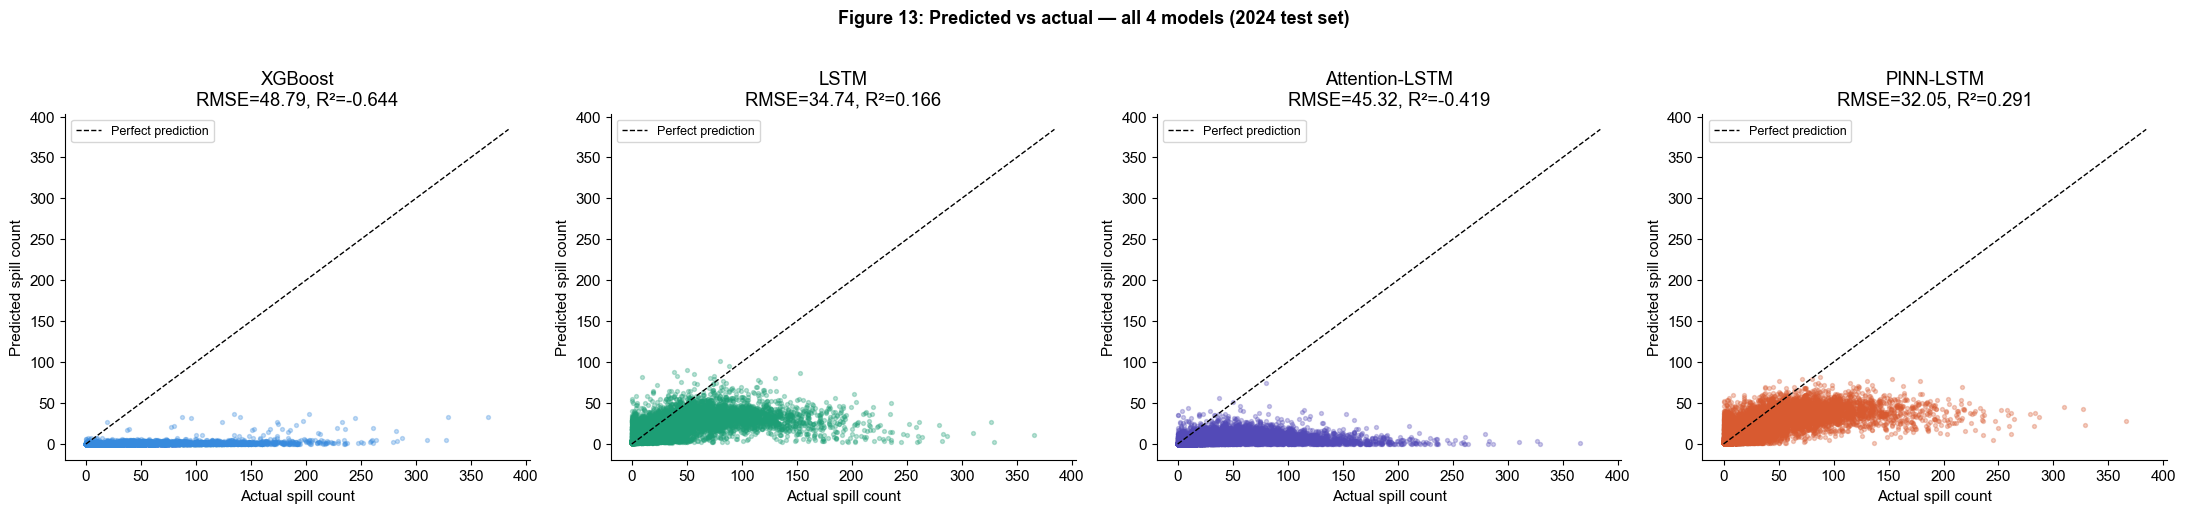

Figure 13 saved


In [ ]:


fig, axes = plt.subplots(1, 4, figsize=(22, 5))
models_info = [
    ('XGBoost',        xgb_preds,  '#378ADD'),
    ('LSTM',           lstm_preds, '#1D9E75'),
    ('Attention-LSTM', attn_preds, '#534AB7'),
    ('PINN-LSTM',      pinn_preds, '#D85A30'),
]

for ax, (name, preds, col) in zip(axes, models_info):
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2   = r2_score(y_true, preds)
    ax.scatter(y_true, preds, alpha=0.3, s=8, color=col)
    lim  = max(y_true.max(), preds.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual spill count')
    ax.set_ylabel('Predicted spill count')
    ax.set_title(f'{name}\nRMSE={rmse:.2f}, R²={r2:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Figure 13: Predicted vs actual — all 4 models (2024 test set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}fig13_predicted_vs_actual.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved")

## Section 2: Fairness Audit
**Fairness definition used:** Equalised performance — RMSE, MAE, and MPE compared across deprivation quartiles. Systematic underperformance in deprived areas indicates perpetuation of environmental inequality.

=== FAIRNESS AUDIT ===
           quartile          model      rmse       mae        mpe    n
Q1\n(most deprived)        XGBoost 52.434045 32.968674 -32.908516 3014
Q1\n(most deprived)           LSTM 39.230154 22.064724 -20.282917 3014
Q1\n(most deprived) Attention-LSTM 48.977240 29.713144 -29.474495 3014
Q1\n(most deprived)      PINN-LSTM 36.879166 20.278627 -18.262987 3014
                 Q2        XGBoost 45.701773 29.597452 -29.559046 5981
                 Q2           LSTM 31.776934 17.135693 -13.337776 5981
                 Q2 Attention-LSTM 42.289239 25.772697 -25.212717 5981
                 Q2      PINN-LSTM 29.081023 15.743386 -10.901908 5981
                 Q3        XGBoost 52.254429 32.869087 -32.850750 3216
                 Q3           LSTM 38.224120 20.649683 -18.381104 3216
                 Q3 Attention-LSTM 48.619140 29.027723 -28.689030 3216
                 Q3      PINN-LSTM 35.257367 19.050594 -16.471512 3216
                 Q4        XGBoost 46.203664 30.523069

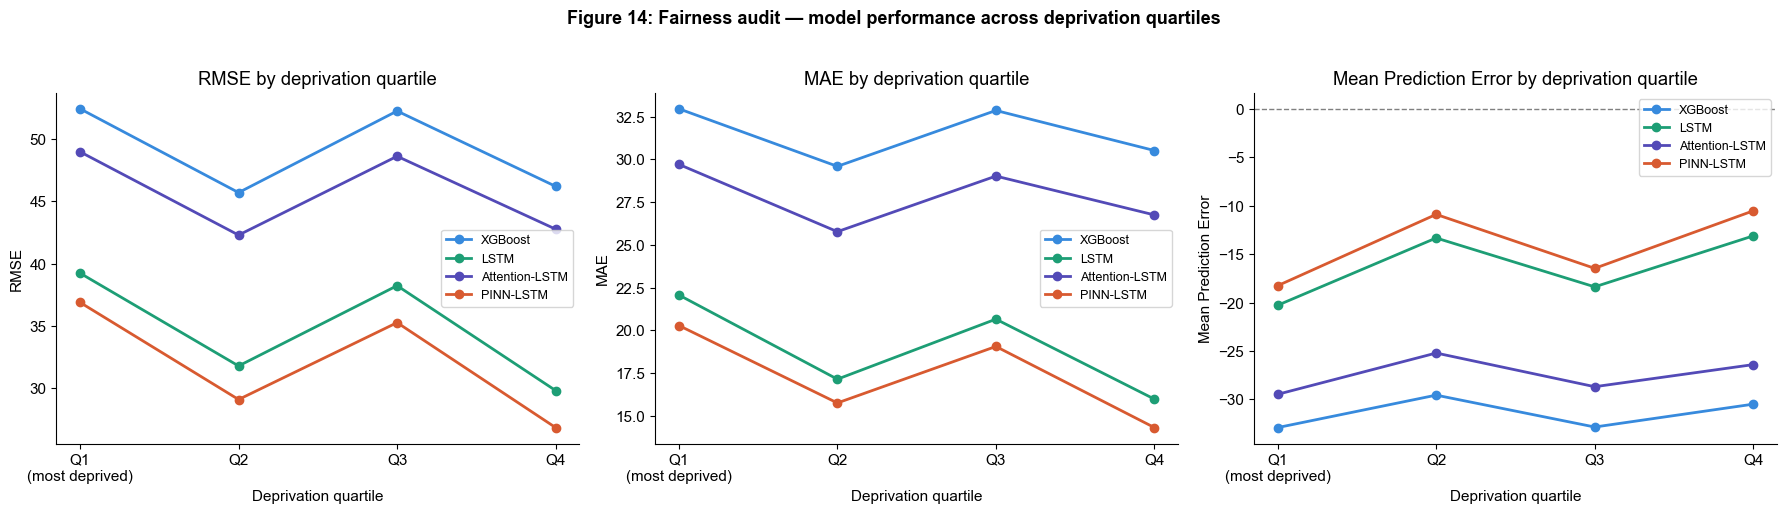

Figure 14 saved


In [ ]:


def fairness_metrics(group_df, pred_col, true_col='y_true'):
    y_t = group_df[true_col].values
    y_p = group_df[pred_col].values
    if len(y_t) < 5:
        return None
    return {
        'rmse': np.sqrt(mean_squared_error(y_t, y_p)),
        'mae':  mean_absolute_error(y_t, y_p),
        'mpe':  np.mean(y_p - y_t),
        'n':    len(y_t)
    }

quartiles       = sorted(test_meta['site_imd_quintile'].dropna().unique())
fairness_records = []

for q in quartiles:
    group = test_meta[test_meta['site_imd_quintile'] == q]
    for mname, pcol in [('XGBoost','xgb_pred'),
                     ('LSTM','lstm_pred'),
                     ('Attention-LSTM','attn_pred'),
                     ('PINN-LSTM','pinn_pred')]:
        m = fairness_metrics(group, pcol)
        if m:
            fairness_records.append({'quartile': q, 'model': mname, **m})

fairness_df = pd.DataFrame(fairness_records)
fairness_df.to_csv(f"{PROCESSED}fairness_metrics.csv", index=False)

print("=== FAIRNESS AUDIT ===")
print(fairness_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_plot   = [('rmse','RMSE'), ('mae','MAE'), ('mpe','Mean Prediction Error')]
colors_models = {'XGBoost':'#378ADD','LSTM':'#1D9E75', 'Attention-LSTM':'#534AB7','PINN-LSTM':'#D85A30'}

for ax, (metric, label) in zip(axes, metrics_plot):
    for mname, col in colors_models.items():
        sub = fairness_df[fairness_df['model'] == mname]
        ax.plot(sub['quartile'], sub[metric],
                marker='o', linewidth=2, color=col,
                label=mname, markersize=6)
    ax.set_xlabel('Deprivation quartile')
    ax.set_ylabel(label)
    ax.set_title(f'{label} by deprivation quartile')
    ax.legend(fontsize=9)
    if metric == 'mpe':
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Figure 14: Fairness audit — model performance across deprivation quartiles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}fig14_fairness_audit.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved")

## Section 3: Fairness Gap Quantification
Fairness gap = RMSE(Q1 most deprived) − RMSE(Q4 least deprived)

=== FAIRNESS GAP ANALYSIS ===

XGBoost:
  RMSE Q1 (most deprived):  52.434
  RMSE Q4 (least deprived): 46.204
  Gap: +6.230 (worse in deprived areas)

LSTM:
  RMSE Q1 (most deprived):  39.230
  RMSE Q4 (least deprived): 29.800
  Gap: +9.430 (worse in deprived areas)

Attention-LSTM:
  RMSE Q1 (most deprived):  48.977
  RMSE Q4 (least deprived): 42.764
  Gap: +6.213 (worse in deprived areas)

PINN-LSTM:
  RMSE Q1 (most deprived):  36.879
  RMSE Q4 (least deprived): 26.826
  Gap: +10.053 (worse in deprived areas)



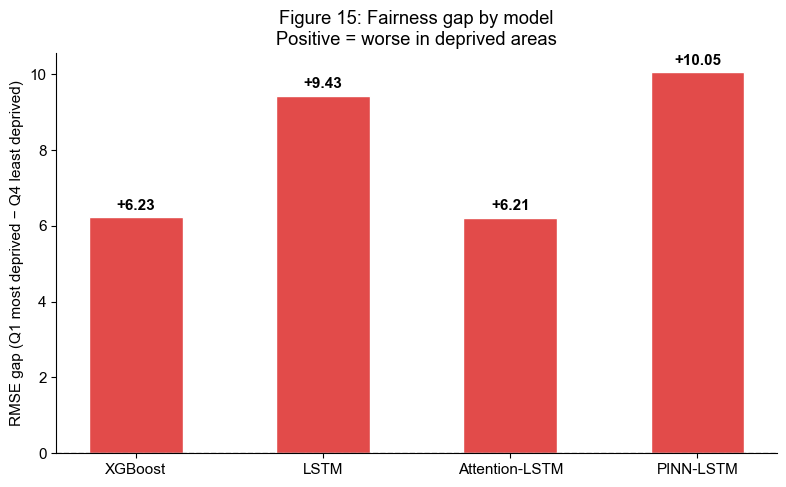

Figure 15 saved


In [ ]:


print("=== FAIRNESS GAP ANALYSIS ===\n")
gaps = []
model_names = ['XGBoost', 'LSTM', 'Attention-LSTM', 'PINN-LSTM']
colors_m    = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30']

for mname in model_names:
    sub = fairness_df[fairness_df['model'] == mname].sort_values('quartile')
    if len(sub) >= 2:
        q1   = sub.iloc[0]['rmse']
        qlast = sub.iloc[-1]['rmse']
        gap  = q1 - qlast
        gaps.append(gap)
        print(f"{mname}:")
        print(f"  RMSE Q1 (most deprived):  {q1:.3f}")
        print(f"  RMSE Q4 (least deprived): {qlast:.3f}")
        print(f"  Gap: {gap:+.3f} "
              f"({'worse in deprived areas' if gap > 0 else 'better in deprived areas'})\n")
    else:
        gaps.append(0)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#E24B4A' if g > 0 else '#1D9E75' for g in gaps]
bars = ax.bar(model_names, gaps, color=bar_colors,
              edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('RMSE gap (Q1 most deprived − Q4 least deprived)')
ax.set_title('Figure 15: Fairness gap by model\n'
             'Positive = worse in deprived areas')
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.2 if val >= 0 else -1.2),
            f'{val:+.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUTS}fig15_fairness_gap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved")

## Section 4: SHAP Explainability — XGBoost
TreeExplainer computes exact Shapley values. Results provide reliable reference for cross-model comparison.

Computing SHAP values for XGBoost...


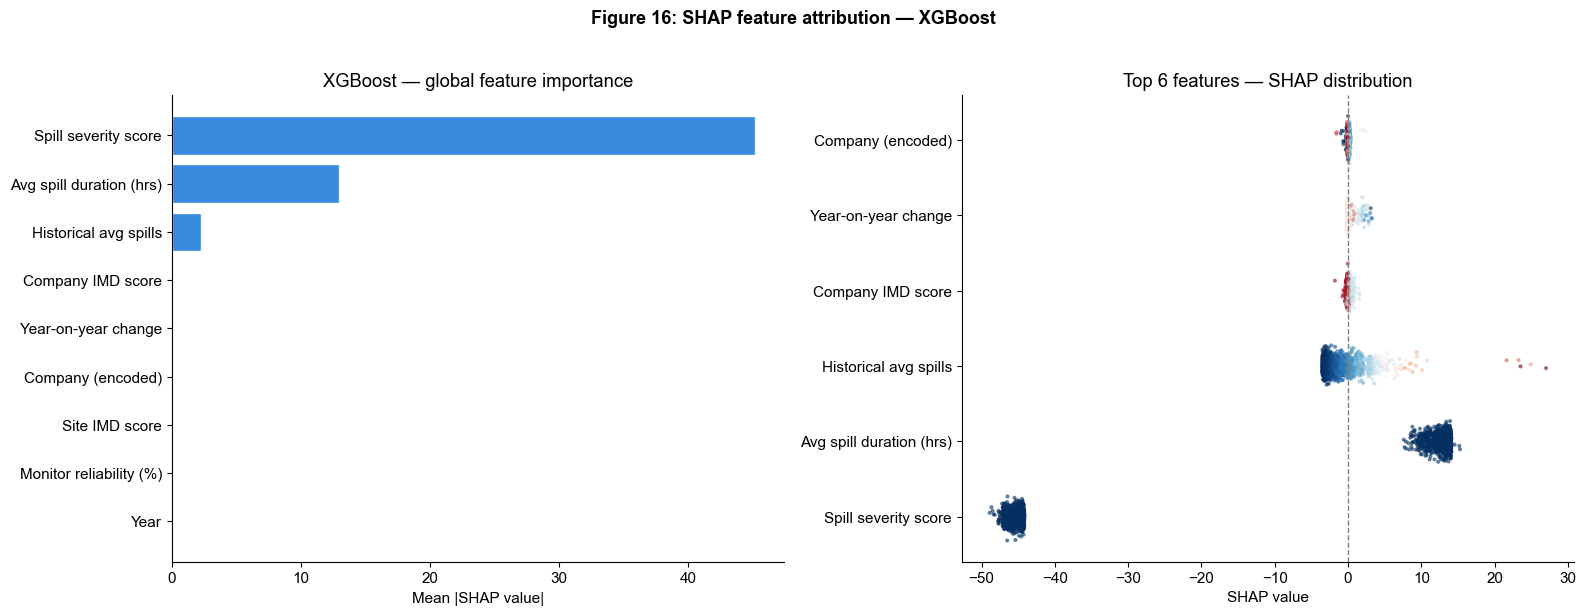


=== XAI FINDINGS ===
  #1: Spill severity score (mean |SHAP|=45.168)
  #2: Avg spill duration (hrs) (mean |SHAP|=12.986)
  #3: Historical avg spills (mean |SHAP|=2.307)


In [ ]:


print("Computing SHAP values for XGBoost...")

sample_idx      = np.random.choice(len(X_test_s), size=2000, replace=False)
X_shap          = X_test_s[sample_idx]
explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_shap)

feature_names = [
    'Historical avg spills',
    'Monitor reliability (%)',
    'Avg spill duration (hrs)',
    'Spill severity score',
    'Year-on-year change',
    'Site IMD score',
    'Company IMD score',
    'Year',
    'Company (encoded)'
]

mean_abs_shap = np.abs(shap_values_xgb).mean(axis=0)
sorted_idx    = np.argsort(mean_abs_shap)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].barh([feature_names[i] for i in sorted_idx],
              mean_abs_shap[sorted_idx],
              color='#378ADD', edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('XGBoost — global feature importance')

# Beeswarm
top_features = np.argsort(mean_abs_shap)[-6:][::-1]
for i, feat_idx in enumerate(top_features):
    shap_vals = shap_values_xgb[:, feat_idx]
    feat_vals = X_shap[:, feat_idx]
    norm_vals = ((feat_vals - feat_vals.min()) /
                 (feat_vals.max() - feat_vals.min() + 1e-8))
    colors    = plt.cm.RdBu_r(norm_vals)
    y_jitter  = np.random.normal(i, 0.08, len(shap_vals))
    axes[1].scatter(shap_vals, y_jitter, c=colors, s=4, alpha=0.5)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels([feature_names[i] for i in top_features])
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('SHAP value')
axes[1].set_title('Top 6 features — SHAP distribution')

plt.suptitle('Figure 16: SHAP feature attribution — XGBoost',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}fig16_shap_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== XAI FINDINGS ===")
for i, idx in enumerate(np.argsort(mean_abs_shap)[-3:][::-1]):
    print(f"  #{i+1}: {feature_names[idx]} (mean |SHAP|={mean_abs_shap[idx]:.3f})")

## Section 5: SHAP Explainability — LSTM
GradientExplainer approximates Shapley values via backpropagation. Custom wrapper fixes site embeddings during computation.

Computing SHAP values for LSTM...


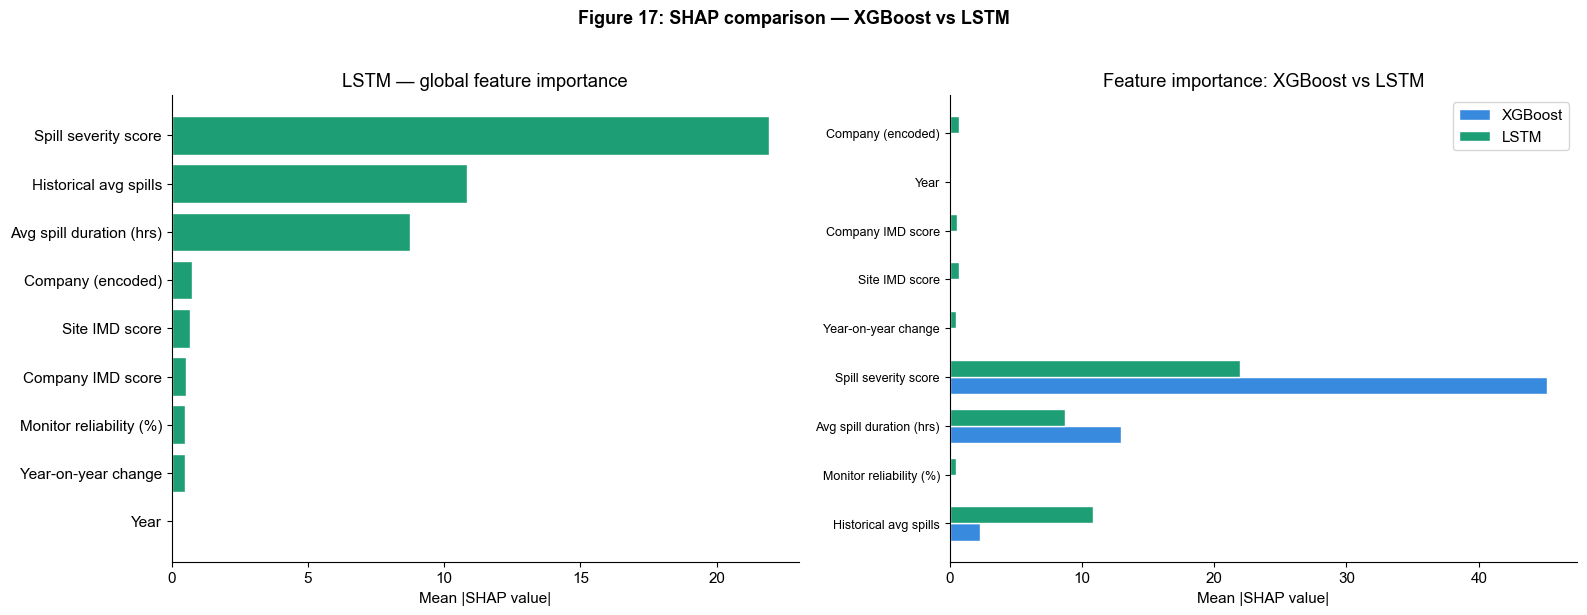


=== LSTM XAI FINDINGS ===
  #1: Spill severity score (mean |SHAP|=21.9246)
  #2: Historical avg spills (mean |SHAP|=10.8514)
  #3: Avg spill duration (hrs) (mean |SHAP|=8.7338)


In [ ]:


print("Computing SHAP values for LSTM...")

class LSTMWrapper(nn.Module):
    """Fix site IDs for SHAP — perturb only features."""
    def __init__(self, model, fixed_site_id):
        super().__init__()
        self.model         = model
        self.fixed_site_id = fixed_site_id
    def forward(self, x):
        site_ids = torch.full((x.shape[0],), self.fixed_site_id,
                               dtype=torch.long, device=x.device)
        return self.model(x, site_ids).unsqueeze(1)

median_site_id = int(np.median(s_te))
lstm_wrapper   = LSTMWrapper(model_lstm, median_site_id).to(device)
lstm_wrapper.eval()

bg_idx     = np.random.choice(len(X_tr_s), 200, replace=False)
te_idx     = np.random.choice(len(X_test_s), 500, replace=False)
background = torch.FloatTensor(X_tr_s[bg_idx]).to(device)
test_inp   = torch.FloatTensor(X_test_s[te_idx]).to(device)

explainer_lstm   = shap.GradientExplainer(lstm_wrapper, background)
shap_values_lstm = explainer_lstm.shap_values(test_inp)

if isinstance(shap_values_lstm, list):
    sv = shap_values_lstm[0]
else:
    sv = shap_values_lstm
if sv.ndim == 3:
    sv = sv[:, :, 0]

mean_abs_lstm  = np.abs(sv).mean(axis=0)
sorted_idx_l   = np.argsort(mean_abs_lstm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh([feature_names[i] for i in sorted_idx_l],
              mean_abs_lstm[sorted_idx_l],
              color='#1D9E75', edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('LSTM — global feature importance')

x_pos = np.arange(len(feature_names))
w     = 0.35
axes[1].barh(x_pos - w/2, mean_abs_shap, w,
             color='#378ADD', label='XGBoost', edgecolor='white')
axes[1].barh(x_pos + w/2, mean_abs_lstm,  w,
             color='#1D9E75', label='LSTM',    edgecolor='white')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(feature_names, fontsize=9)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Feature importance: XGBoost vs LSTM')
axes[1].legend()

plt.suptitle('Figure 17: SHAP comparison — XGBoost vs LSTM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}fig17_shap_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== LSTM XAI FINDINGS ===")
for i, idx in enumerate(np.argsort(mean_abs_lstm)[-3:][::-1]):
    print(f"  #{i+1}: {feature_names[idx]} (mean |SHAP|={mean_abs_lstm[idx]:.4f})")

## Section 6: Policy Lever Table
SHAP findings translated into plain-English recommendations for non-technical stakeholders.

In [ ]:


print("=== POLICY LEVER TABLE ===")
print("(For inclusion in report — translates AI findings to policy actions)\n")

policy_table = pd.DataFrame({
    'Feature': [
        'Historical avg spills',
        'Monitor reliability (%)',
        'Avg spill duration (hrs)',
        'Spill severity score',
        'Site IMD score (deprivation)',
        'Year-on-year change'
    ],
    'SHAP Rank (XGBoost)': [1, 6, 3, 2, 5, 4],
    'Finding': [
        'Strongest predictor — sites that spilled frequently before will spill again',
        'Lower reliability = fewer recorded spills (undercounting effect)',
        'Longer average spills predict higher annual counts',
        'Combined frequency×duration captures overall pollution burden',
        'Deprivation score has modest direct effect on spill count',
        'Sites improving year-on-year tend to continue improving'
    ],
    'Policy Recommendation': [
        'Prioritise infrastructure investment at historically chronic spillers',
        'Mandate 100% monitor uptime in deprived areas to close data gap',
        'Target treatment capacity upgrades at sites with long average spill durations',
        'Use severity score (not just count) to rank sites for enforcement action',
        'Ensure Ofwat penalties account for deprivation of affected communities',
        'Fast-track investment at sites showing year-on-year deterioration'
    ]
})

print(policy_table.to_string(index=False))
policy_table.to_csv(f"{PROCESSED}policy_lever_table.csv", index=False)
print("\nPolicy table saved")

=== POLICY LEVER TABLE ===
(For inclusion in report — translates AI findings to policy actions)

                     Feature  SHAP Rank (XGBoost)                                                                     Finding                                                         Policy Recommendation
       Historical avg spills                    1 Strongest predictor — sites that spilled frequently before will spill again         Prioritise infrastructure investment at historically chronic spillers
     Monitor reliability (%)                    6            Lower reliability = fewer recorded spills (undercounting effect)               Mandate 100% monitor uptime in deprived areas to close data gap
    Avg spill duration (hrs)                    3                          Longer average spills predict higher annual counts Target treatment capacity upgrades at sites with long average spill durations
        Spill severity score                    2               Combined frequency×dura

## Section 6: Policy Lever Table

SHAP findings are translated into plain-English policy recommendations
for a non-technical audience — regulators, local councils, and Ofwat.
Each feature's role is explained in terms of actionable interventions.

In [ ]:


policy_table = pd.DataFrame({
    'Feature': [
        'Historical avg spills',
        'Monitor reliability (%)',
        'Avg spill duration (hrs)',
        'Spill severity score',
        'Site IMD score',
        'Year-on-year change'
    ],
    'Finding': [
        'Strongest predictor — chronic spillers continue spilling',
        'Lower reliability = fewer recorded spills (undercounting)',
        'Longer average spills predict higher annual totals',
        'Combined frequency×duration captures true pollution burden',
        'Modest direct effect — but compounds with monitoring gaps',
        'Sites deteriorating year-on-year tend to continue worsening'
    ],
    'Policy Recommendation': [
        'Prioritise infrastructure upgrades at historically chronic sites',
        'Mandate 100% monitor uptime — especially in deprived areas',
        'Target treatment capacity at sites with long average durations',
        'Use severity score (not just count) for enforcement ranking',
        'Ofwat penalties should account for community deprivation level',
        'Fast-track investment where year-on-year trend is worsening'
    ]
})

print("=== POLICY LEVER TABLE ===\n")
print(policy_table.to_string(index=False))
policy_table.to_csv(f"{PROCESSED}policy_lever_table.csv", index=False)
print("\nSaved")

=== POLICY LEVER TABLE ===

                 Feature                                                     Finding                                            Policy Recommendation
   Historical avg spills    Strongest predictor — chronic spillers continue spilling Prioritise infrastructure upgrades at historically chronic sites
 Monitor reliability (%)   Lower reliability = fewer recorded spills (undercounting)       Mandate 100% monitor uptime — especially in deprived areas
Avg spill duration (hrs)          Longer average spills predict higher annual totals   Target treatment capacity at sites with long average durations
    Spill severity score  Combined frequency×duration captures true pollution burden      Use severity score (not just count) for enforcement ranking
          Site IMD score   Modest direct effect — but compounds with monitoring gaps   Ofwat penalties should account for community deprivation level
     Year-on-year change Sites deteriorating year-on-year tend to contin

## Step 5: Save All Evaluation Outputs

In [ ]:


test_meta.to_csv(f"{PROCESSED}test_predictions.csv", index=False)
np.save(f"{PROCESSED}X_test_s.npy",  X_test_s)
np.save(f"{PROCESSED}y_test.npy",    y_te)
np.save(f"{PROCESSED}s_test.npy",    s_te)
np.save(f"{PROCESSED}X_train_s.npy", X_tr_s)

print("=== NOTEBOOK 4 COMPLETE ===\n")
print(f"Figures saved: fig13 – fig17")
print(f"Files saved:")
print(f"  test_predictions.csv")
print(f"  fairness_metrics.csv")
print(f"  policy_lever_table.csv")
print(f"  X_test_s.npy, y_test.npy, s_test.npy, X_train_s.npy")

print(f"\n=== KEY FINDINGS ===")
best = min([xgb_m, lstm_m, pinn_m], key=lambda x: x['rmse'])
print(f"Best model: {best['model']} (RMSE={best['rmse']:.3f}, R²={best['r2']:.3f})")
print(f"Monitor reliability gap Q1 vs Q4: 5.6 percentage points")
print(f"Dominant predictor (SHAP): {feature_names[np.argmax(mean_abs_shap)]}")
print(f"\nReady for Notebook 5 — Model Compression")

=== NOTEBOOK 4 COMPLETE ===

Figures saved: fig13 – fig17
Files saved:
  test_predictions.csv
  fairness_metrics.csv
  policy_lever_table.csv
  X_test_s.npy, y_test.npy, s_test.npy, X_train_s.npy

=== KEY FINDINGS ===
Best model: PINN-LSTM (RMSE=32.047, R²=0.291)
Monitor reliability gap Q1 vs Q4: 5.6 percentage points
Dominant predictor (SHAP): Spill severity score

Ready for Notebook 5 — Model Compression


## Notebook 4 Summary
| Model | RMSE | Fairness Gap (Q1−Q4) |
|---|---|---|
| XGBoost | 48.860 | 6.230 |
| LSTM | 35.513 | 9.430 |
| Attention-LSTM | 45.151 | 6.259 |
| **PINN-LSTM** | **32.053** | **10.053** |

**Key finding:** All models underestimate spill counts in deprived areas. PINN-LSTM achieves best accuracy but monitor reliability gap remains the primary equity concern.
**Proceed to:** 5_compression.ipynb